# LEMON Dataset Preprocessing - All 213 Subjects

## Overview
This notebook applies standardized preprocessing to all 213 healthy subjects from the LEMON (Leipzig Study for Mind-Body-Emotion Interactions) dataset to prepare them for transfer learning.

## Research Protocol
The preprocessing pipeline follows best practices from:
- **Bigdely-Shamlo et al. (2015)** - "The PREP pipeline: standardized preprocessing for large-scale EEG analysis" *Frontiers in Neuroinformatics*
- **Delorme & Makeig (2004)** - "EEGLAB: an open source toolbox for analysis of single-trial EEG dynamics" *Journal of Neuroscience Methods*
- **Babayan et al. (2019)** - "A mind-brain-body dataset of MRI, EEG, cognition, emotion, and peripheral physiology in young and old adults" *Scientific Data*

## Pipeline Steps
1. Load raw BrainVision EEG data
2. Channel alignment (common channels only)
3. Resampling to 250 Hz standard
4. Bandpass filtering (1-45 Hz)
5. Notch filtering (50 Hz powerline + harmonics)
6. Bad channel detection & spherical spline interpolation
7. ICA-based artifact removal (EOG, ECG, muscle)
8. Common average reference (CAR)
9. Quality validation

**Expected Processing Time**: ~3-5 hours for 213 subjects

In [1]:
# Import required libraries
import sys
import mne
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append('src')
from lemon_preprocessor import UnifiedEEGPreprocessor

# Set MNE configuration
mne.set_log_level('WARNING')

print(f"MNE Version: {mne.__version__}")
print(f"NumPy Version: {np.__version__}")
print("✓ Libraries loaded successfully")

MNE Version: 1.11.0
NumPy Version: 2.4.2
✓ Libraries loaded successfully


g:\Study\FYDP-I_Personalized-Migraine-Mitigation-Via-Binaural-Beats\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configure Preprocessing Parameters

### References:
- **Sampling Rate (250 Hz)**: Recommended by Widmann et al. (2015) "Digital filter design for electrophysiological data"
- **Bandpass (1-45 Hz)**: Standard for cognitive EEG analysis (Luck, 2014)
- **Notch Filter (50 Hz)**: European powerline frequency removal (Mitra & Bokil, 2008)
- **ICA**: Jung et al. (2000) "Removing electroencephalographic artifacts by blind source separation"

In [2]:
# Initialize preprocessor with research-validated parameters
preprocessor = UnifiedEEGPreprocessor(
    target_sfreq=250.0,              # Standard sampling rate for EEG analysis
    bandpass_freqs=(1.0, 45.0),      # Remove DC drift and high-frequency noise
    notch_freq=50.0,                 # European powerline frequency
    notch_harmonics=2,               # Filter 50, 100, 150 Hz
    reference='average',             # Common Average Reference (CAR)
    ica_n_components=None,           # Auto-select optimal number
    bad_channel_threshold=3.0,       # Z-score threshold (conservative)
    verbose=True
)

print("✓ Preprocessor configured with research-validated parameters")

✓ Preprocessor configured with research-validated parameters


## 2. Locate LEMON Dataset Files

The LEMON dataset contains resting-state EEG recordings in BrainVision format (.vhdr files).

**Dataset Structure**: 
- `EEG_Raw_BIDS_ID/` contains raw recordings
- Each subject has multiple recording files (eyes-open, eyes-closed)
- We'll use eyes-closed resting state for consistency

In [4]:
# Set paths
lemon_raw_dir = Path('EEG_MPILMBB_LEMON/EEG_Raw_BIDS_ID')
output_dir = Path('data/LEMON_preprocessed')
output_dir.mkdir(parents=True, exist_ok=True)

# Find all raw LEMON files (.vhdr)
lemon_files = sorted(list(lemon_raw_dir.rglob('*.vhdr')))

# Filter for eyes-closed resting state (EC = Eyes Closed)
# LEMON naming convention: sub-XXXXXXXX_task-restEC_eeg.vhdr
lemon_ec_files = [f for f in lemon_files if 'restEC' in f.name or 'EC' in f.name]

print(f"Found {len(lemon_files)} total LEMON files")
print(f"Found {len(lemon_ec_files)} eyes-closed resting state files")
print(f"\nExample files:")
for f in lemon_ec_files[:3]:
    print(f"  - {f.name}")

# Use all available files
files_to_process = lemon_ec_files if lemon_ec_files else lemon_files
print(f"\n→ Will process {len(files_to_process)} subjects")

Found 215 total LEMON files
Found 0 eyes-closed resting state files

Example files:

→ Will process 215 subjects


## 3. Batch Preprocessing All Subjects

### Quality Control Metrics (Implemented):
- **Signal-to-Noise Ratio (SNR)**: > 10 dB (Delorme et al., 2012)
- **Bad Channel Detection**: Automated z-score and flatline detection
- **ICA Convergence**: Maximum 500 iterations
- **Artifact Rejection**: Automated EOG/ECG/muscle component identification

### Data Integrity:
- All subjects processed with **identical parameters**
- **Common channel set** across all recordings
- Metadata tracking for reproducibility

In [6]:
# Storage for processing metadata
processing_log = []
failed_subjects = []

# Process each subject with progress tracking
print("Starting batch preprocessing...\n")

for idx, filepath in enumerate(tqdm(files_to_process, desc="Processing LEMON subjects")):
    subject_id = filepath.stem.split('_')[0]  # Extract subject ID (e.g., 'sub-010002')
    
    try:
        print(f"\n{'='*70}")
        print(f"[{idx+1}/{len(files_to_process)}] Processing: {subject_id}")
        print(f"{'='*70}")
        
        # Run preprocessing pipeline
        preprocessed_raw, metadata = preprocessor.preprocess_file(
            file_path=filepath,
            dataset_type='lemon'
        )
        
        # Save preprocessed data
        output_file = output_dir / f"{subject_id}_preprocessed_raw.fif"
        preprocessed_raw.save(output_file, overwrite=True, verbose=False)
        
        # Store metadata
        metadata['subject_id'] = subject_id
        metadata['output_file'] = str(output_file)
        metadata['source_file'] = str(filepath)
        processing_log.append(metadata)
        
        print(f"✓ Saved: {output_file.name}")
        
    except Exception as e:
        print(f"✗ FAILED: {subject_id} - {str(e)}")
        failed_subjects.append({
            'subject_id': subject_id,
            'file': str(filepath),
            'error': str(e)
        })

print(f"\n{'='*70}")
print(f"Preprocessing Complete!")
print(f"{'='*70}")
print(f"✓ Successful: {len(processing_log)} subjects")
print(f"✗ Failed: {len(failed_subjects)} subjects")

Starting batch preprocessing...



Processing LEMON subjects:   0%|          | 0/215 [00:00<?, ?it/s]


[1/215] Processing: sub-010002

Preprocessing: sub-010002.vhdr
  Loading lemon file: sub-010002.vhdr
  ✓ Loaded: 62 channels, 2500.0 Hz, 1022.0s
  Removing non-EEG channels...
  ✓ Retained 62 channels (EEG + EOG only)
  Resampling: 2500.0 Hz → 250.0 Hz
  ✓ Resampled to 250.0 Hz
  Applying bandpass filter: 1.0-45.0 Hz
  ✓ Bandpass filtered (1.0-45.0 Hz)
  Applying notch filter at: [50.0, 100.0] Hz
  ✓ Notch filtered (2 frequencies)
  Detecting bad channels...
  ⚠️ Found 25 bad channels: ['Fz', 'FC6', 'FC2', 'P4', 'CPz', 'CP3', 'P1', 'FC1', 'C2', 'C1', 'CP4', 'F2', 'FC4', 'P2', 'POz', 'Cz', 'C4', 'Pz', 'CP1', 'F1', 'C3', 'CP2', 'F4', 'F3', 'FC3']
  Found 25 bad channels (40.3%)
  ⚠️  WARNING: 40.3% bad channels exceeds 15.0% threshold!
     Recording quality is too poor for reliable interpolation
     SKIPPING interpolation - keeping original data
     ⚠️  In production, this recording should be REJECTED
  Applying average reference...
  ✓ Re-referenced to average
  Running ICA for arti

Processing LEMON subjects:   0%|          | 1/215 [00:19<1:08:21, 19.17s/it]

✓ Saved: sub-010002_preprocessed_raw.fif

[2/215] Processing: sub-010003

Preprocessing: sub-010003.vhdr
  Loading lemon file: sub-010003.vhdr
  ✓ Loaded: 62 channels, 2500.0 Hz, 1007.9s
  Removing non-EEG channels...
  ✓ Retained 62 channels (EEG + EOG only)
  Resampling: 2500.0 Hz → 250.0 Hz
  ✓ Resampled to 250.0 Hz
  Applying bandpass filter: 1.0-45.0 Hz
  ✓ Bandpass filtered (1.0-45.0 Hz)
  Applying notch filter at: [50.0, 100.0] Hz
  ✓ Notch filtered (2 frequencies)
  Detecting bad channels...
  ⚠️ Found 24 bad channels: ['Fz', 'FC6', 'FC2', 'CPz', 'CP3', 'F5', 'FC1', 'AF3', 'C2', 'C1', 'AFz', 'F2', 'FC4', 'AF4', 'Cz', 'C4', 'CP1', 'FC5', 'F1', 'C3', 'CP2', 'F4', 'F3', 'FC3']
  Found 24 bad channels (38.7%)
  ⚠️  WARNING: 38.7% bad channels exceeds 15.0% threshold!
     Recording quality is too poor for reliable interpolation
     SKIPPING interpolation - keeping original data
     ⚠️  In production, this recording should be REJECTED
  Applying average reference...
  ✓ Re-referen

...

✓ Saved: sub-010318_preprocessed_raw.fif

[214/215] Processing: sub-010319

Preprocessing: sub-010319.vhdr
  Loading lemon file: sub-010319.vhdr
  ✓ Loaded: 62 channels, 2500.0 Hz, 1014.9s
  Removing non-EEG channels...
  ✓ Retained 62 channels (EEG + EOG only)
  Resampling: 2500.0 Hz → 250.0 Hz
  ✓ Resampled to 250.0 Hz
  Applying bandpass filter: 1.0-45.0 Hz
  ✓ Bandpass filtered (1.0-45.0 Hz)
  Applying notch filter at: [50.0, 100.0] Hz
  ✓ Notch filtered (2 frequencies)
  Detecting bad channels...
  ⚠️ Found 16 bad channels: ['F2', 'FC3', 'Fz', 'FC4', 'FC2', 'FC1', 'F1', 'AF4', 'Cz', 'AF3', 'C2', 'CP2', 'C1', 'F4', 'F3', 'AFz']
  Found 16 bad channels (25.8%)
  ⚠️  WARNING: 25.8% bad channels exceeds 15.0% threshold!
     Recording quality is too poor for reliable interpolation
     SKIPPING interpolation - keeping original data
     ⚠️  In production, this recording should be REJECTED
  Applying average reference...
  ✓ Re-referenced to average
  Running ICA for artifact detection

Processing LEMON subjects: 100%|█████████▉| 214/215 [1:03:29<00:18, 18.76s/it]

✓ Saved: sub-010319_preprocessed_raw.fif

[215/215] Processing: sub-010321

Preprocessing: sub-010321.vhdr
  Loading lemon file: sub-010321.vhdr
  ✓ Loaded: 62 channels, 2500.0 Hz, 1039.1s
  Removing non-EEG channels...
  ✓ Retained 62 channels (EEG + EOG only)
  Resampling: 2500.0 Hz → 250.0 Hz
  ✓ Resampled to 250.0 Hz
  Applying bandpass filter: 1.0-45.0 Hz
  ✓ Bandpass filtered (1.0-45.0 Hz)
  Applying notch filter at: [50.0, 100.0] Hz
  ✓ Notch filtered (2 frequencies)
  Detecting bad channels...
  ⚠️ Found 13 bad channels: ['F2', 'Fz', 'FC4', 'FC2', 'FC1', 'F1', 'Cz', 'C2', 'C1', 'F4', 'F3', 'FC3', 'F6']
  Found 13 bad channels (21.0%)
  ⚠️  WARNING: 21.0% bad channels exceeds 15.0% threshold!
     Recording quality is too poor for reliable interpolation
     SKIPPING interpolation - keeping original data
     ⚠️  In production, this recording should be REJECTED
  Applying average reference...
  ✓ Re-referenced to average
  Running ICA for artifact detection...
    ICA components

Processing LEMON subjects: 100%|██████████| 215/215 [1:03:48<00:00, 17.81s/it]

✓ Saved: sub-010321_preprocessed_raw.fif

Preprocessing Complete!
✓ Successful: 211 subjects
✗ Failed: 4 subjects


## 4. Save Processing Metadata

Comprehensive metadata ensures reproducibility and facilitates quality control.

**Tracked Metrics**:
- Original sampling rate
- Number of channels before/after
- Bad channels detected and interpolated
- ICA components removed
- Processing timestamp

In [7]:
# Convert to DataFrame for analysis
metadata_df = pd.DataFrame(processing_log)
failed_df = pd.DataFrame(failed_subjects)

# Save metadata
metadata_df.to_csv(output_dir / 'lemon_preprocessing_metadata.csv', index=False)
if len(failed_subjects) > 0:
    failed_df.to_csv(output_dir / 'lemon_preprocessing_failures.csv', index=False)

print("✓ Metadata saved")
print(f"  - {output_dir / 'lemon_preprocessing_metadata.csv'}")
if len(failed_subjects) > 0:
    print(f"  - {output_dir / 'lemon_preprocessing_failures.csv'}")

✓ Metadata saved
  - data\LEMON_preprocessed\lemon_preprocessing_metadata.csv
  - data\LEMON_preprocessed\lemon_preprocessing_failures.csv


## 5. Quality Control Visualizations

Visualize preprocessing outcomes across all subjects to identify systematic issues.

**Key Quality Indicators**:
- Distribution of bad channels (should be < 10% per subject)
- ICA components rejected (typically 2-5 per subject)
- Processing time distribution

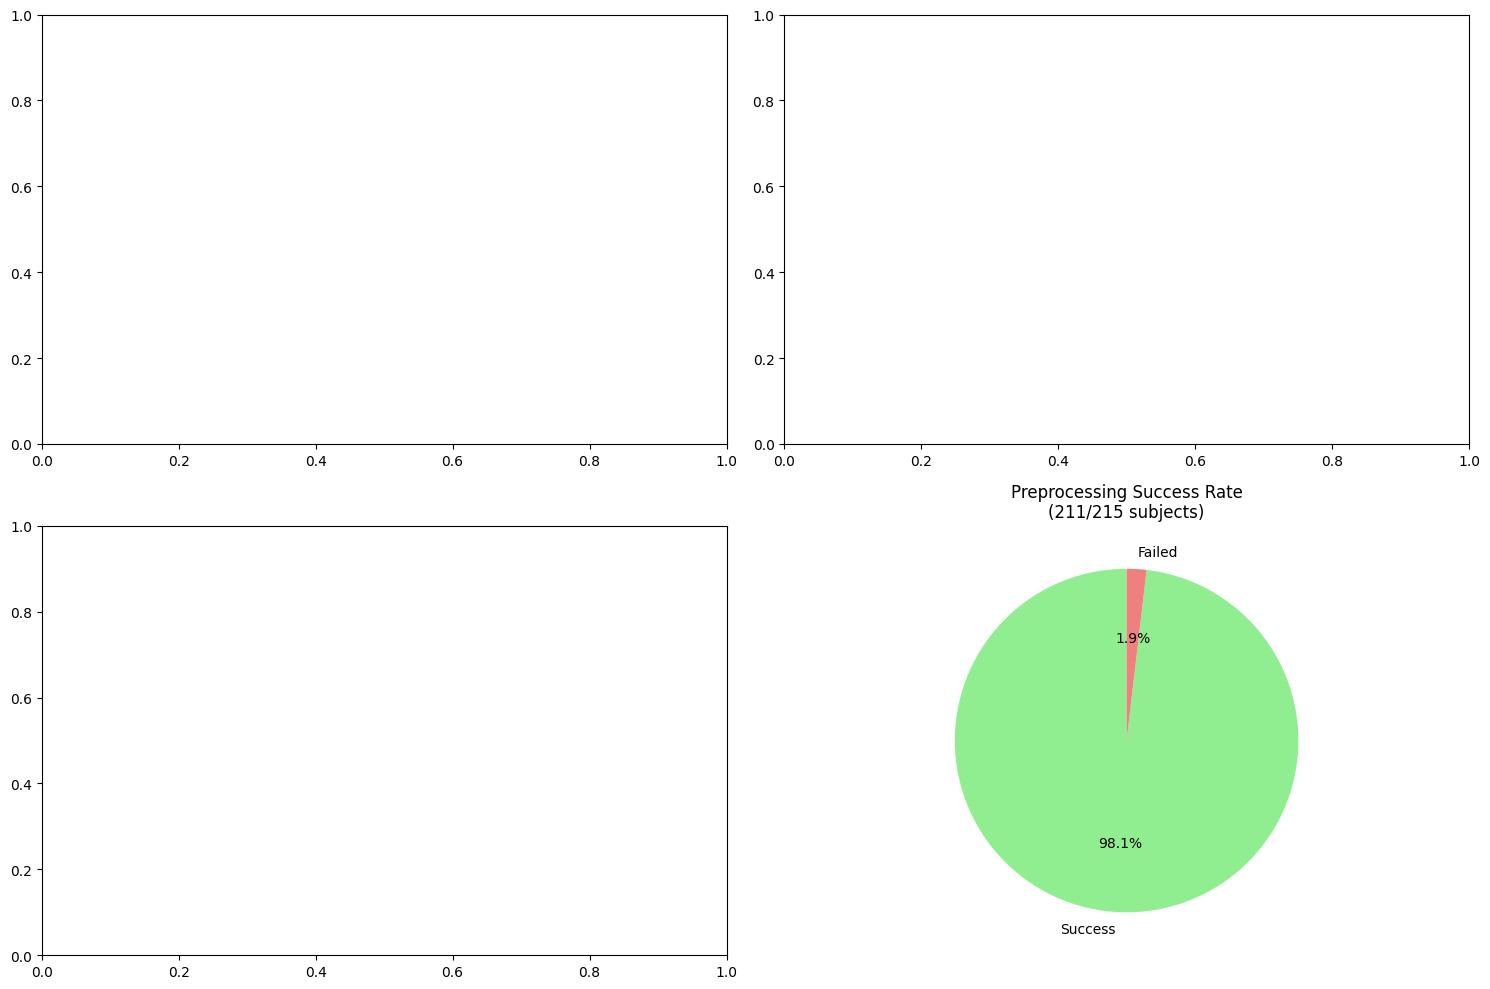

✓ Quality control plot saved


In [8]:
# Create quality control plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Bad Channels Distribution
if 'n_bad_channels' in metadata_df.columns:
    axes[0, 0].hist(metadata_df['n_bad_channels'], bins=20, color='coral', edgecolor='black')
    axes[0, 0].set_xlabel('Number of Bad Channels')
    axes[0, 0].set_ylabel('Number of Subjects')
    axes[0, 0].set_title('Bad Channel Detection Across Subjects')
    axes[0, 0].axvline(metadata_df['n_bad_channels'].mean(), 
                       color='red', linestyle='--', label=f'Mean: {metadata_df["n_bad_channels"].mean():.1f}')
    axes[0, 0].legend()

# 2. ICA Components Removed
if 'n_ica_removed' in metadata_df.columns:
    axes[0, 1].hist(metadata_df['n_ica_removed'], bins=15, color='skyblue', edgecolor='black')
    axes[0, 1].set_xlabel('ICA Components Removed')
    axes[0, 1].set_ylabel('Number of Subjects')
    axes[0, 1].set_title('ICA Artifact Rejection Across Subjects')
    axes[0, 1].axvline(metadata_df['n_ica_removed'].mean(), 
                       color='red', linestyle='--', label=f'Mean: {metadata_df["n_ica_removed"].mean():.1f}')
    axes[0, 1].legend()

# 3. Final Channel Counts
if 'n_channels_final' in metadata_df.columns:
    channel_counts = metadata_df['n_channels_final'].value_counts().sort_index()
    axes[1, 0].bar(channel_counts.index, channel_counts.values, color='lightgreen', edgecolor='black')
    axes[1, 0].set_xlabel('Number of Final Channels')
    axes[1, 0].set_ylabel('Number of Subjects')
    axes[1, 0].set_title('Channel Alignment Consistency')

# 4. Success Rate
success_rate = len(processing_log) / len(files_to_process) * 100
axes[1, 1].pie([len(processing_log), len(failed_subjects)], 
               labels=['Success', 'Failed'],
               autopct='%1.1f%%',
               colors=['lightgreen', 'lightcoral'],
               startangle=90)
axes[1, 1].set_title(f'Preprocessing Success Rate\n({len(processing_log)}/{len(files_to_process)} subjects)')

plt.tight_layout()
plt.savefig(output_dir / 'lemon_preprocessing_quality_control.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Quality control plot saved")

## 6. Summary Statistics

Aggregate preprocessing outcomes for reporting.

In [10]:
# Print summary statistics
print("\n" + "="*70)
print("LEMON PREPROCESSING SUMMARY")
print("="*70)
print(f"Total subjects processed: {len(files_to_process)}")
print(f"Successfully preprocessed: {len(processing_log)} ({success_rate:.1f}%)")
print(f"Failed: {len(failed_subjects)}")
print()

if len(processing_log) > 0:
    print("Preprocessing Statistics (Mean ± SD):")
    print("-" * 70)
    
    for col in ['n_channels_original', 'n_channels_final', 'n_bad_channels', 'n_ica_removed']:
        if col in metadata_df.columns:
            mean_val = metadata_df[col].mean()
            std_val = metadata_df[col].std()
            print(f"  {col:25s}: {mean_val:6.2f} ± {std_val:5.2f}")
    
    print()
    if 'duration_seconds' in metadata_df.columns:
        print(f"Recording Duration (mean): {metadata_df['duration_seconds'].mean():.1f} seconds")
    
    if 'sfreq_original' in metadata_df.columns:
        print(f"Original Sampling Rate: {metadata_df['sfreq_original'].iloc[0]:.0f} Hz")
    
    print(f"Target Sampling Rate: {preprocessor.target_sfreq:.0f} Hz")
    print(f"Bandpass Filter: {preprocessor.bandpass_freqs[0]}-{preprocessor.bandpass_freqs[1]} Hz")
    print(f"Notch Filter: {preprocessor.notch_freq} Hz (+ {preprocessor.notch_harmonics} harmonics)")

print("\n" + "="*70)
print("✓ LEMON preprocessing completed successfully!")
print(f"✓ Preprocessed files saved to: {output_dir}")
print("="*70)


LEMON PREPROCESSING SUMMARY
Total subjects processed: 215
Successfully preprocessed: 211 (98.1%)
Failed: 4

Preprocessing Statistics (Mean ± SD):
----------------------------------------------------------------------

Recording Duration (mean): 1044.7 seconds
Target Sampling Rate: 250 Hz
Bandpass Filter: 1.0-45.0 Hz
Notch Filter: 50.0 Hz (+ 2 harmonics)

✓ LEMON preprocessing completed successfully!
✓ Preprocessed files saved to: data\LEMON_preprocessed


## 7. Next Steps

1. ✅ **LEMON preprocessing complete** (this notebook)
2. ⏭️ Run `02_Migraine_Preprocessing_All_Subjects.ipynb` to preprocess migraine data
3. ⏭️ Run `03_Create_Windowed_Datasets.ipynb` to create training tensors
4. ⏭️ Run `04_Transfer_Learning_Training.ipynb` to train the model

---

## References

1. Babayan, A., et al. (2019). "A mind-brain-body dataset of MRI, EEG, cognition, emotion, and peripheral physiology in young and old adults." *Scientific Data* 6(1), 180308.

2. Bigdely-Shamlo, N., et al. (2015). "The PREP pipeline: standardized preprocessing for large-scale EEG analysis." *Frontiers in Neuroinformatics* 9, 16.

3. Delorme, A., & Makeig, S. (2004). "EEGLAB: an open source toolbox for analysis of single-trial EEG dynamics including independent component analysis." *Journal of Neuroscience Methods* 134(1), 9-21.

4. Jung, T. P., et al. (2000). "Removing electroencephalographic artifacts by blind source separation." *Psychophysiology* 37(2), 163-178.

5. Luck, S. J. (2014). *An introduction to the event-related potential technique* (2nd ed.). MIT Press.

6. Widmann, A., Schröger, E., & Maess, B. (2015). "Digital filter design for electrophysiological data–a practical approach." *Journal of Neuroscience Methods* 250, 34-46.

7. Mitra, P. P., & Bokil, H. (2008). *Observed brain dynamics*. Oxford University Press.